TASK 1: DATA LOADING, MERGING, DEEP EXPLORATION

Import the dependencies first step and from this up is on step which is virtual environment make and then dependency

In [1]:
import numpy as np
import pandas as pd
import datetime as dt

Data loading and displayed 10 rows of data

In [2]:
df = pd.read_csv("./dataset/train.csv")
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


Checking Data type of columns and total structured data information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

Converting Order date, Ship date dtype into datetime

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")

These are new columns made for evaluate month wise year wise sales.
there is order id dividing into categorized day, month, year.

In [5]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()
df["Season"] = df["Order Date"].dt.quarter
df["Quarter"] = df["Order Date"].dt.quarter

After add columns display and there is extra quarter column which is for season define

In [6]:
df.head(7)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day,Season,Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,4
1,2,CA-2017-152156,2017-11-08,2017-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,4
2,3,CA-2017-138688,2017-06-12,2017-06-12,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,2
3,4,US-2016-108966,2016-10-11,2016-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,4
4,5,US-2016-108966,2016-10-11,2016-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,4
5,6,CA-2015-115812,2015-06-09,2015-06-09,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,2015,6,24,Tuesday,2,2
6,7,CA-2015-115812,2015-06-09,2015-06-09,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Office Supplies,Art,Newell 322,7.2800,2015,6,24,Tuesday,2,2


There is ["Season"] column is defined by Quarter which is year divided into 4 parts then there is defined (jan-march = Spring, April-june = Summer, july-sept = Rainy, Oct-dec = Winter) {from numeric value to season name}

In [7]:
df["Season"] = df["Season"].replace({1:"Spring", 2:"Summer", 3:"Raint", 4:"Winter"})

Cheching there null values.

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day               0
Season            0
Quarter           0
dtype: int64

There is the summary of overall data.

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Year,Month,Week,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.0,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469,2017-05-01 05:13:51.673469,55273.322403,230.769059,2016.724184,7.818469,32.210102,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-03 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.0,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-24 00:00:00,23223.000000,17.248000,2016.000000,5.000000,21.0,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-26 00:00:00,58103.000000,54.490000,2017.000000,9.000000,35.0,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-15 00:00:00,90008.000000,210.605000,2018.000000,11.000000,45.0,4.000000
max,9800.000000,2018-12-30 00:00:00,2018-12-30 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,53.0,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,14.282294,1.057449


Cheching there all columns are corrected.

In [10]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day,Season,Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,Winter,4
1,2,CA-2017-152156,2017-11-08,2017-11-08,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,Winter,4
2,3,CA-2017-138688,2017-06-12,2017-06-12,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,Summer,2
3,4,US-2016-108966,2016-10-11,2016-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,Winter,4
4,5,US-2016-108966,2016-10-11,2016-10-11,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,Winter,4


Checking there duplicate value

In [11]:
df.duplicated().sum()

np.int64(0)

Aggregation data.
There is daily sales data.

In [12]:
daily_sales = df.groupby("Order Date", as_index=False)["Sales"].sum()
print(daily_sales)

     Order Date      Sales
0    2015-01-03    16.4480
1    2015-01-04   288.0600
2    2015-01-05    19.5360
3    2015-01-06  4407.1000
4    2015-01-07    87.1580
...         ...        ...
1225 2018-12-26   814.5940
1226 2018-12-27   177.6360
1227 2018-12-28  1657.3508
1228 2018-12-29  2915.5340
1229 2018-12-30   713.7900

[1230 rows x 2 columns]


That analysis is weekly sales display

In [13]:
weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)
print("----That is between 4 years data(2015-2018) ----\n",weekly_sales.head(22))

----That is between 4 years data(2015-2018) ----
    Order Date      Sales
0  2015-01-04    304.508
1  2015-01-11   4619.108
2  2015-01-18   4130.533
3  2015-01-25   3092.544
4  2015-02-01   2527.914
5  2015-02-08    968.534
6  2015-02-15   2771.054
7  2015-02-22    224.912
8  2015-03-01   2289.643
9  2015-03-08   4030.728
10 2015-03-15   4139.602
11 2015-03-22  37703.665
12 2015-03-29   3998.777
13 2015-04-05  10363.902
14 2015-04-12   8418.293
15 2015-04-19   2198.370
16 2015-04-26   5660.104
17 2015-05-03   4974.812
18 2015-05-10   6332.464
19 2015-05-17   3967.870
20 2015-05-24   6241.984
21 2015-05-31   6523.233


There is displayed month wise sales.

In [14]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)
print(monthly_sales)

   Order Date        Sales
0  2015-01-31   14205.7070
1  2015-02-28    4519.8920
2  2015-03-31   55205.7970
3  2015-04-30   27906.8550
4  2015-05-31   23644.3030
5  2015-06-30   34322.9356
6  2015-07-31   33781.5430
7  2015-08-31   27117.5365
8  2015-09-30   81623.5268
9  2015-10-31   31453.3930
10 2015-11-30   77907.6607
11 2015-12-31   68167.0585
12 2016-01-31   18066.9576
13 2016-02-29   11951.4110
14 2016-03-31   32339.3184
15 2016-04-30   34154.4685
16 2016-05-31   29959.5305
17 2016-06-30   23599.3740
18 2016-07-31   28608.2590
19 2016-08-31   36818.3422
20 2016-09-30   63133.6060
21 2016-10-31   31011.7375
22 2016-11-30   75249.3995
23 2016-12-31   74543.6012
24 2017-01-31   18542.4910
25 2017-02-28   22978.8150
26 2017-03-31   51165.0590
27 2017-04-30   38679.7670
28 2017-05-31   56656.9080
29 2017-06-30   39724.4860
30 2017-07-31   38320.7830
31 2017-08-31   30542.2003
32 2017-09-30   69193.3909
33 2017-10-31   59583.0330
34 2017-11-30   79066.4958
35 2017-12-31   95739.1210
3

Q.1- Which product category generates the highest total revenue?

Ans. There observed the most highest revenue product category is Technology.

In [15]:
Category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("--- Category wise sales ---\n\n", Category_sales)


--- Category wise sales ---

 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


○ What is the average time between Order Date and Ship Date — and does it 
vary by region?

-  There is analyzed no difference btw order date and ship date there is value zero and also no vary by the region.

In [16]:
# Convert columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Calculate shipping days (.dt.days converts the timedelta into a clean integer)
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

overall_avg = df["Shipping Days"].mean()
print(f"Overall shipping avg: {overall_avg:.2f} days")

region_varies = df.groupby("Region")["Shipping Days"].mean().reset_index().sort_values(by="Shipping Days")
print(region_varies)



Overall shipping avg: 0.00 days
    Region  Shipping Days
0  Central            0.0
1     East            0.0
2    South            0.0
3     West            0.0


Aggregate sales (leaves Region and Year as a MultiIndex).
Calculate YoY growth percentage within each region level.
Combine them into a clean, flat DataFrame for plotting.


In [17]:
region_growth = df.groupby(["Region", "Year"])["Sales"].sum()

yoy_growth = region_growth.groupby(level="Region").pct_change() * 100

final_df = region_growth.to_frame(name="Sales")
final_df["YoY Growth %"] = yoy_growth
final_df = final_df.reset_index()

print(final_df)

     Region  Year        Sales  YoY Growth %
0   Central  2015  102920.5206           NaN
1   Central  2016  102425.1724     -0.481292
2   Central  2017  145673.8800     42.224686
3   Central  2018  141627.3402     -2.777807
4      East  2015  127652.8190           NaN
5      East  2016  153225.1830     20.032745
6      East  2017  178511.5380     16.502741
7      East  2018  210129.1860     17.711823
8     South  2015  103374.9055           NaN
9     South  2016   70076.0825    -32.211708
10    South  2017   93535.9035     33.477643
11    South  2018  122164.5675     30.607139
12     West  2015  145907.9630           NaN
13     West  2016  133709.5675     -8.360336
14     West  2017  182471.2285     36.468341
15     West  2018  248130.9255     35.983589


○ Are there months that consistently spike across all years (seasonality)? 
- November month is highest sales by month wise(Which is the winter season).

In [18]:
most_monthSales = df.groupby("Month")["Sales"].sum().sort_values(ascending=False)
print(most_monthSales)

Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64


That is the total sales of november month in every year.

In [19]:
df[df["Month"] == 11].groupby("Year")["Sales"].sum()

Year
2015     77907.6607
2016     75249.3995
2017     79066.4958
2018    117938.1550
Name: Sales, dtype: float64

TASK 2: TIME SERIES ANALYSIS AND DECOMPOSITION

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

● Plot the overall monthly sales trend across all 4 years.


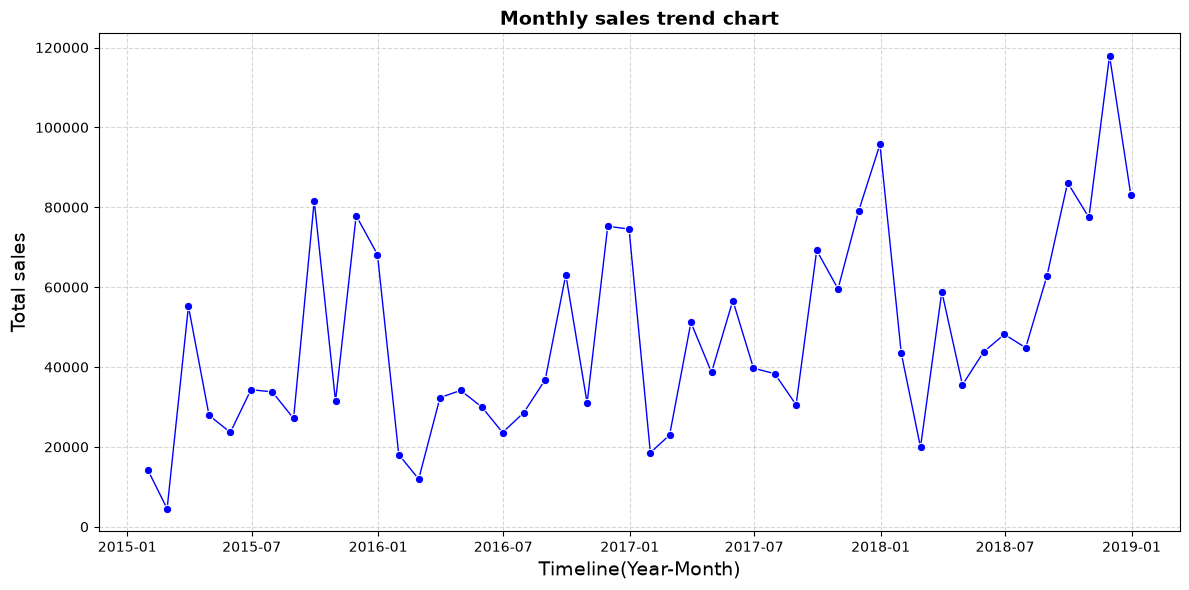

In [21]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_sales,
    x="Order Date",
    y="Sales",
    marker="o",
    linewidth=1,
    color= "Blue")
plt.title("Monthly sales trend chart",fontsize=14,fontweight = "bold")
plt.xlabel("Timeline(Year-Month)",fontsize=14)
plt.ylabel("Total sales",fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("./charts/MonthlySales.jpg")
plt.show()


By this trend chart i'm analyzed overall trend of sales across 4 years 2015-18, 2015-2016 very must gonna be sales growth and after starting 2016 decreasing sales till half of this year, according to analysis winter time is having a great season when sales is growthing that was peak time for company.

There is one of the most important analysis after drop 2015 starting year sales we go for another years of stating period there is downfall in every year every starting year and end of the year is must be growth.

At the end of monthly sales analysis increased every year sales that is great sign for company.

In [22]:
from sklearn.decomposition import PCA
from statsmodels.tsa.seasonal import seasonal_decompose

In [23]:
result = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)
result.trend


0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6     40148.902783
7     40619.434850
8     39976.311533
9     39283.858821
10    39807.310529
11    39623.629942
12    38961.261375
13    39149.908113
14    38783.694983
15    37994.879304
16    37865.716108
17    38020.644504
18    38306.147675
19    38785.436733
20    40029.317758
21    41002.277721
22    42303.222554
23    44087.492950
24    45164.061117
25    45307.243704
26    45298.228829
27    46741.190512
28    48090.706838
29    49132.899175
30    51054.961792
31    51966.468683
32    52159.824358
33    52349.845062
34    51684.479117
35    51502.617279
36    52126.390725
37    53743.056087
38    55795.353787
39    57246.378592
40    59610.410150
41    60700.532108
42             NaN
43             NaN
44             NaN
45             NaN
46             NaN
47             NaN
Name: trend, dtype: float64

We are seen that trend result there is NaN values which is comes by the uses of seasonal_decomposer() it make data in pattern it is very must approach to find patterns with data sales. 

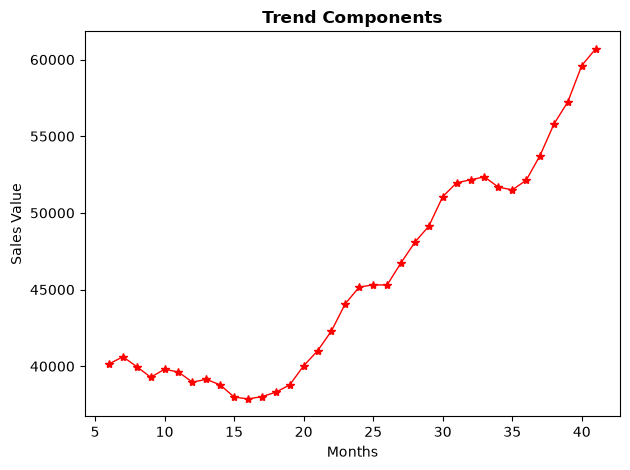

In [24]:
plt.plot(result.trend,color='r',linewidth=1,marker='*')
plt.title("Trend Components",fontweight="bold")
plt.xlabel("Months")
plt.ylabel("Sales Value")
plt.tight_layout()
plt.savefig("./charts/trendComponents.jpg")

In [25]:
result.seasonal

0    -18307.338037
1    -27368.402667
2      1244.763035
3    -10787.508768
4     -4626.878630
5    -11698.570528
6     -9185.216915
7    -11883.161587
8     27676.282185
9     -3114.680533
10    33224.106768
11    34826.605678
12   -18307.338037
13   -27368.402667
14     1244.763035
15   -10787.508768
16    -4626.878630
17   -11698.570528
18    -9185.216915
19   -11883.161587
20    27676.282185
21    -3114.680533
22    33224.106768
23    34826.605678
24   -18307.338037
25   -27368.402667
26     1244.763035
27   -10787.508768
28    -4626.878630
29   -11698.570528
30    -9185.216915
31   -11883.161587
32    27676.282185
33    -3114.680533
34    33224.106768
35    34826.605678
36   -18307.338037
37   -27368.402667
38     1244.763035
39   -10787.508768
40    -4626.878630
41   -11698.570528
42    -9185.216915
43   -11883.161587
44    27676.282185
45    -3114.680533
46    33224.106768
47    34826.605678
Name: seasonal, dtype: float64

Make seasonal analysis in plot bcoz in visualized data insight find and understand data so much easy, there is perfectly matching month to month sales starting of the year is always down and 10,11 month which is festive and holidays time that is peak time for company.

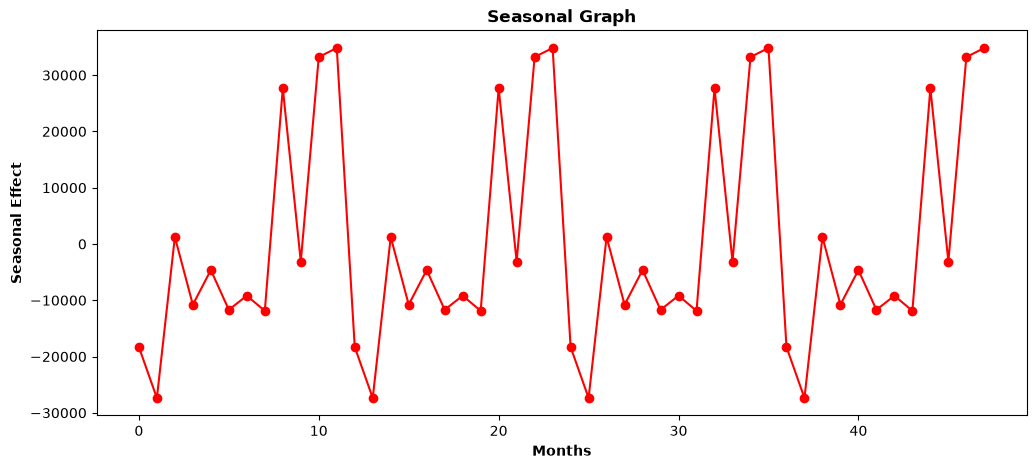

In [26]:
result.seasonal.plot(figsize=(12,5),color='r',marker='o')
plt.title("Seasonal Graph",fontweight='bold')
plt.xlabel("Months",fontweight='bold')
plt.ylabel("Seasonal Effect",fontweight='bold')
plt.savefig("./charts/seasonalChart")


In [27]:
result.resid

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
6      2817.857132
7     -1618.736763
8     13970.933082
9     -4715.785288
10     4876.243403
11    -6283.177120
12    -2586.965738
13      169.905554
14    -7689.139618
15     6947.097964
16    -3279.306978
17    -2722.699977
18     -512.671760
19     9916.067054
20    -4571.993943
21    -6875.859688
22     -277.929822
23    -4370.497428
24    -8314.232079
25     5039.973962
26     4622.067136
27     2726.085255
28    13193.079793
29     2290.157353
30    -3548.961877
31    -9541.106796
32   -10642.715643
33    10347.868471
34    -5842.090085
35     9409.898043
36     9657.421312
37    -6453.656021
38     1823.295978
39   -10916.959724
40   -11157.549320
41     -811.233881
42             NaN
43             NaN
44             NaN
45             NaN
46             NaN
47             NaN
Name: resid, dtype: float64

That analysis show points are showing which is unpredictable sales like in 13 month sales is very low and sudden 8th month sales gone very there are probable for low is because supply chain is stoped, stock is unavailable and in the grow where probable for offers applied.

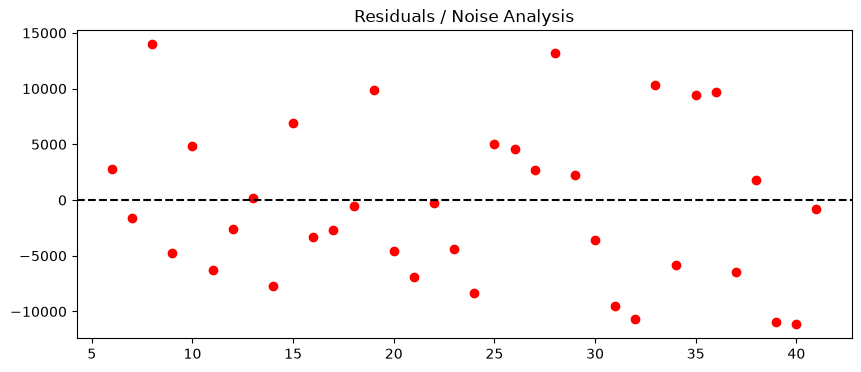

In [28]:
result.resid.plot(title="Residuals / Noise Analysis", figsize=(10, 4), color='red', style='o')
plt.axhline(0, color='black', linestyle='--')
plt.savefig("./charts/NoiseAnalysis.jpg")
plt.show()

In [29]:
result.observed

0      14205.7070
1       4519.8920
2      55205.7970
3      27906.8550
4      23644.3030
5      34322.9356
6      33781.5430
7      27117.5365
8      81623.5268
9      31453.3930
10     77907.6607
11     68167.0585
12     18066.9576
13     11951.4110
14     32339.3184
15     34154.4685
16     29959.5305
17     23599.3740
18     28608.2590
19     36818.3422
20     63133.6060
21     31011.7375
22     75249.3995
23     74543.6012
24     18542.4910
25     22978.8150
26     51165.0590
27     38679.7670
28     56656.9080
29     39724.4860
30     38320.7830
31     30542.2003
32     69193.3909
33     59583.0330
34     79066.4958
35     95739.1210
36     43476.4740
37     19920.9974
38     58863.4128
39     35541.9101
40     43825.9822
41     48190.7277
42     44825.1040
43     62837.8480
44     86152.8880
45     77448.1312
46    117938.1550
47     83030.3888
Name: Sales, dtype: float64

There is original dataset where seen that patterns are real and why is it.

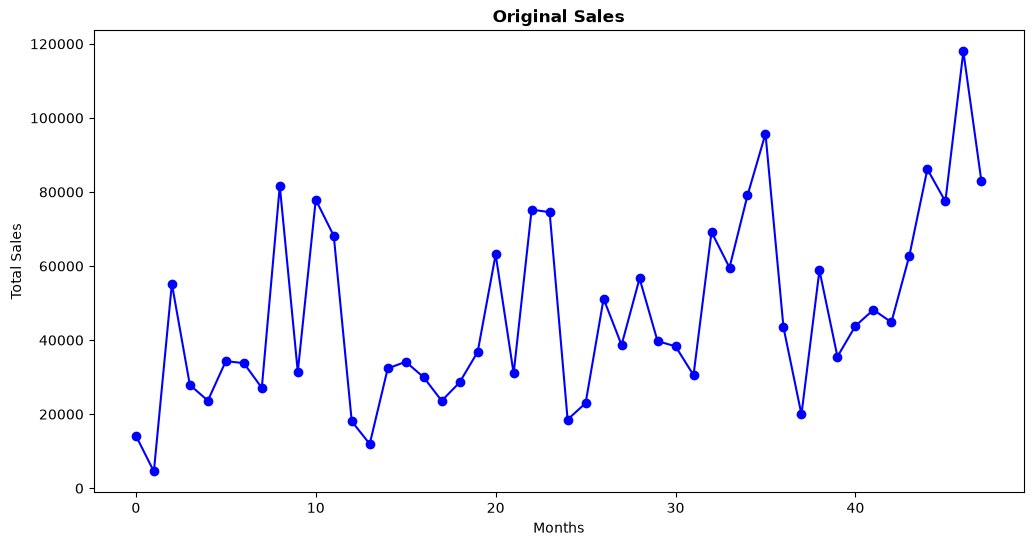

In [30]:
result.observed.plot(figsize=(12,6),color='b',marker='o')
plt.xlabel("Months")
plt.ylabel("Total Sales")
plt.title("Original Sales",fontweight='bold')
plt.savefig("./charts/Original sales.jpg")

<Figure size 1200x1000 with 0 Axes>

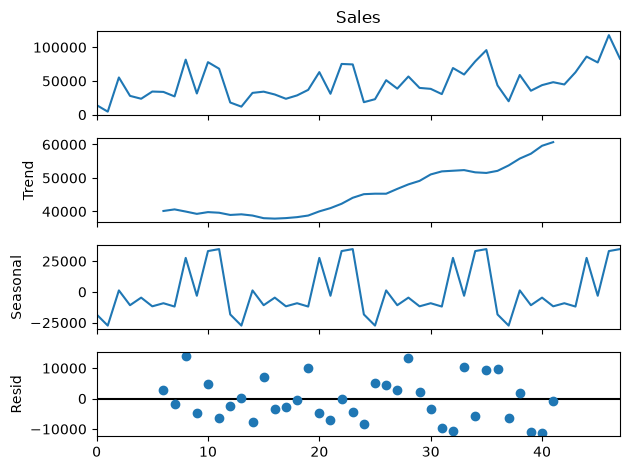

In [31]:
plt.figure(figsize=(12, 10))
result.plot()
plt.tight_layout()
plt.savefig("./charts/OverAll")
plt.show()

Now ADF testing there is first step install dependencies.

In [32]:
from statsmodels.tsa.stattools import adfuller


ADF result is shows the overall test result there monthly sales data is a already stationary(That is surprising but when analysis residual graph that'll understand).(Stationary that means data pattern is controlled)

adfuller which is important part to evaluate important values which is P value check some critical values, that is important part of ADF testing.

In [33]:
adf_result = adfuller(monthly_sales["Sales"])


p_value = adf_result[1]
print(adf_result)

(np.float64(-4.416136761430769), np.float64(0.00027791039276670623), 0, 47, {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}, np.float64(847.3050446881931))


Displayed values.

In [34]:
print("ADF Stastics: ",adf_result[0])
print("P Value: ",adf_result[1])
print("Critical Values: ",adf_result[4])

ADF Stastics:  -4.416136761430769
P Value:  0.00027791039276670623
Critical Values:  {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}


For proven data is stationary.

In [35]:
if adf_result[1] < 0.5:
    print("Data is stationary")
else:
    print("Data is not in stationary")
  

Data is stationary


TASK 3: SALES FORCASTING USING MODELS (SARIMA, FACEBOOK PROPHET, XGBOOST)

MODEL 1: SARIMA(Seasonal autoregressive integrated moving average).


Install dependencies is the firt at all.


In [36]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [37]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]
print(train.shape)
print(test.shape)

(36, 2)
(12, 2)


Given the parameteres of SARIMA model there passes values.

In [38]:
model_s = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,0,12)
)
sarima_model = model_s.fit()

c:\Users\Shivam\Downloads\End to end sales forcasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Shivam\Downloads\End to end sales forcasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Several SARIMA configurations were evaluated. SARIMA(1,0,1)(1,0,1,12) achieved the lowest AIC (1075.83) among the tested models, improving over the initial SARIMA(1,0,1)(1,0,1,12) model (AIC 1075.572). Although one coefficient (ar.L2) was not statistically significant and the covariance matrix warning suggests some parameter instability, the model produced the best overall fit based on AIC and satisfactory residual diagnostics.

In [39]:
sarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               Sales   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -406.562
Date:                             Mon, 13 Jul 2026   AIC                            821.123
Time:                                     15:20:33   BIC                            827.457
Sample:                                          0   HQIC                           823.334
                                              - 36                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9585      0.157      6.114      0.000       0.651       1.266
ma.L1         -0.6832      0.613     -1.115      0.265      -1.884       0.518
ar.S.L12       0.6588      0.243      2.713      0.007       0.183       1.135
sigma2      5.173e+08   2.42e-10   2.14e+18      0.000    5.17e+08    5.17e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):                 1.27
Prob(Q):                              0.63   Prob(JB):                         0.53
Heteroskedasticity (H):               0.50   Skew:                             0.46
Prob(H) (two-sided):                  0.25   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.06e+35. Standard errors may be unstable.
"""

Because the data  points are less hence warnings are displayed. Then now forcasting future months sales.

In this step gonna 12 months future predicting and forecast is a container where sales values are store.

In [40]:
forecast = sarima_model.get_forecast(steps=3)
forecast = sarima_model.get_forecast(steps=len(test))

Then that is display of objects which is contained.

In [41]:
forecast_df=forecast.summary_frame()


Because mean value is main data point of predicted sales then that is future months sales.

In [42]:
sarima_pred = forecast.predicted_mean
confidence_interval= forecast.conf_int()
print(sarima_pred)

36    41391.107016
37    43103.594254
38    60511.580754
39    51175.183173
40    61952.094856
41    49776.430766
42    47872.708365
43    41810.118194
44    66372.179640
45    59179.123149
46    71187.453303
47    81378.410260
Name: predicted_mean, dtype: float64


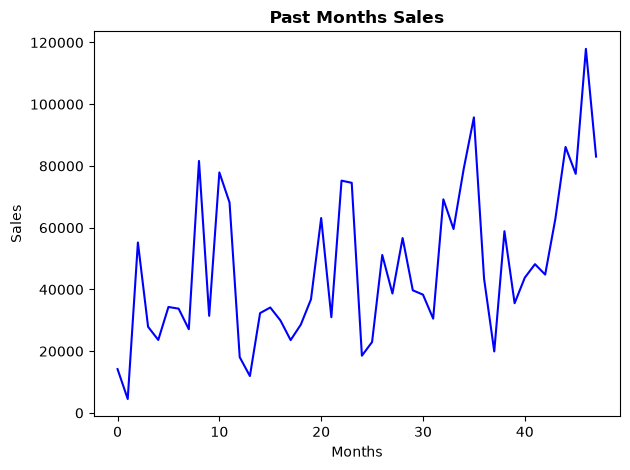

In [43]:
plt.Figure(figsize=(12,5))
sns.lineplot(
    data= monthly_sales["Sales"],color='b'
)
plt.title("Past Months Sales",fontweight='bold',fontsize=12)
plt.xlabel("Months")
plt.tight_layout()
plt.savefig("./charts/S-Overall Sales.jpg")
plt.show()

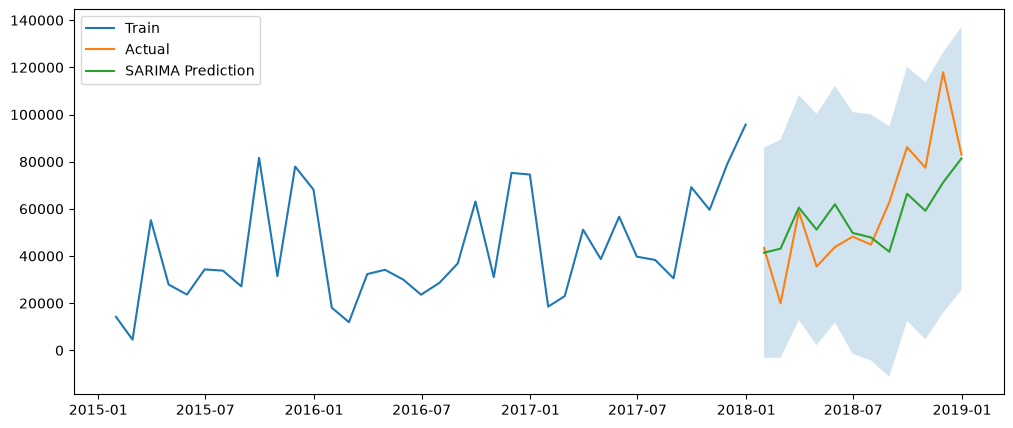

In [44]:
plt.figure(figsize=(12,5))

plt.plot(train["Order Date"], train["Sales"], label="Train")

plt.plot(test["Order Date"], test["Sales"], label="Actual")

plt.plot(test["Order Date"], sarima_pred,
         label="SARIMA Prediction")

plt.fill_between(
    test["Order Date"],
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2
)

plt.legend()
plt.savefig("./charts/Sarima forcast.jpg")

plt.show()

Another type of anlysis which is professionally type.
there is calculating fututre date via order date and periods limit is 12 months freq is defined for monthly end calculate,
and confidence interval is show the limits of risk like safe zone and risk zone of sales limits show that's all.

In [45]:
future_dates = pd.date_range(
    start=monthly_sales["Order Date"].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)
confidence_interval = forecast.conf_int()
print(confidence_interval.head(3))

     lower Sales    upper Sales
36  -3186.273663   85968.487696
37  -3132.678144   89339.866652
38  12801.970478  108221.191030


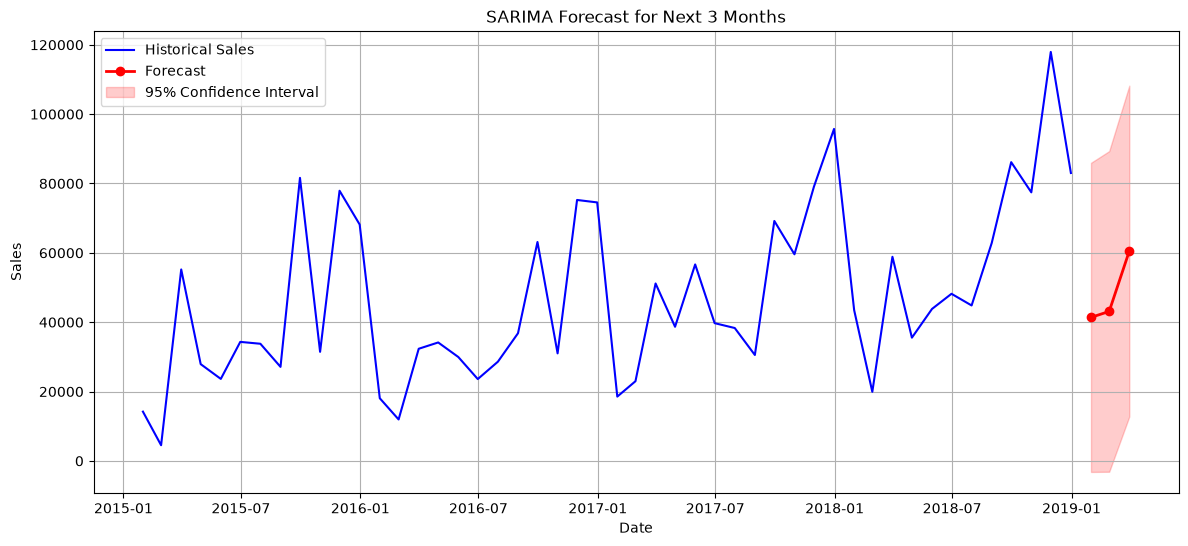

In [46]:
plt.figure(figsize=(14,6))

# Historical Sales
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    label="Historical Sales",
    color="blue"
)

# Forecast
plt.plot(
    future_dates,
    forecast_df["mean"].iloc[: len(future_dates)],
    label="Forecast",
    color="red",
    marker="o",
    linewidth=2
)

# Confidence Interval
plt.fill_between(
    future_dates,
    confidence_interval.iloc[: len(future_dates), 0],
    confidence_interval.iloc[: len(future_dates), 1],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast for Next 3 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("./charts/S-future 3 month.jpg")
plt.show()

forecast Interpretation says that,

The SARIMA model was used to forecast sales for the next three months. The predicted sales values are approximately 55,000, 35,000, and 67,000 units. The forecast suggests a temporary decline in the second month followed by recovery in the third month. The wide 95% confidence intervals indicate uncertainty in the predictions due to fluctuations in historical sales.

MODEL: 2 - FACEBOOK PROPHET  that model is made by facebook(meta), that is for time series data.

In [47]:
from prophet import Prophet

c:\Users\Shivam\Downloads\End to end sales forcasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rule first for prophet transform data name into ds,y.

In [48]:
prophet_df = monthly_sales.rename(columns={"Order Date":"ds","Sales":"y"})
prophet_df.head(3)

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797


In [49]:
train_prophet = prophet_df.iloc[:-12]
test_prophet = prophet_df.iloc[-12:]

In [50]:
model_fb = Prophet(yearly_seasonality=True,weekly_seasonality=False)

In [51]:
model_fb.fit(train_prophet)

15:20:36 - cmdstanpy - INFO - Chain [1] start processing
15:20:37 - cmdstanpy - INFO - Chain [1] done processing


There is y means sales and hat means predict

In [52]:
future= model_fb.make_future_dataframe(periods=12,freq='ME')
forecast = model_fb.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

           ds          yhat    yhat_lower    yhat_upper
45 2018-10-31  50900.787409  42951.993497  58294.490411
46 2018-11-30  89710.818739  82369.342474  97500.987500
47 2018-12-31  89211.294928  81938.650710  96354.535804


In [53]:
prophet_pred = forecast.tail(12)["yhat"].values
print(prophet_pred)

[27276.51185744 22184.01663701 62221.87652722 43283.74435639
 45039.20190013 45162.14660359 45236.46363937 40311.29528394
 86532.35765258 50900.78740852 89710.81873893 89211.29492836]


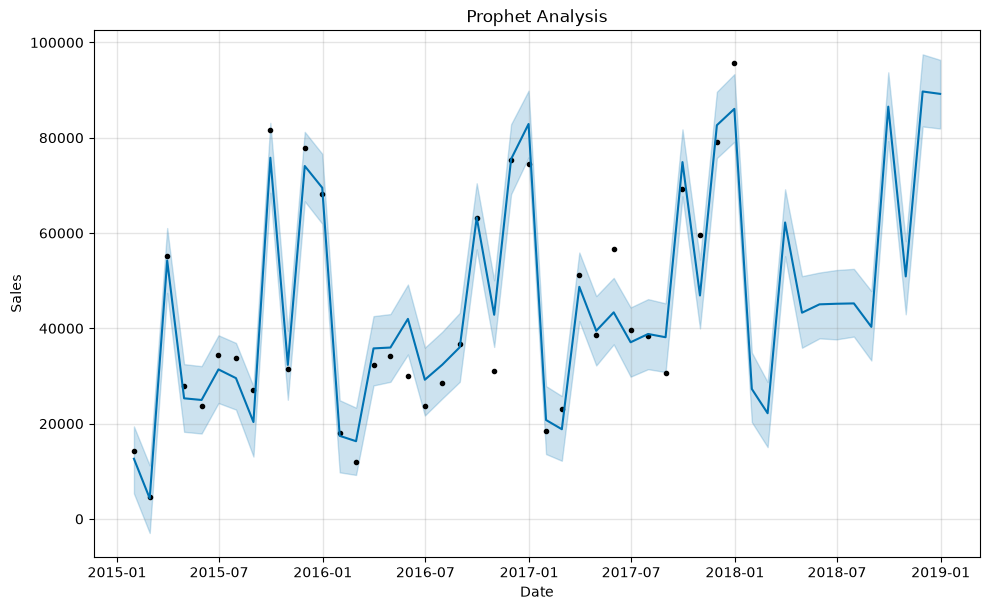

In [54]:
plt.Figure(figsize=(12,5))
model_fb.plot(forecast)
plt.title("Prophet Analysis")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()



There in prophet analysis black dot is a actual sales points and blue line is predicted sales.
it follows historical pattern.
The Prophet model successfully learned the historical sales trend and yearly seasonal patterns. The forecast indicates that sales continue to follow a recurring seasonal cycle while maintaining an overall upward trend. The prediction interval widens slightly for future months, reflecting increased uncertainty as the forecasting horizon extends.

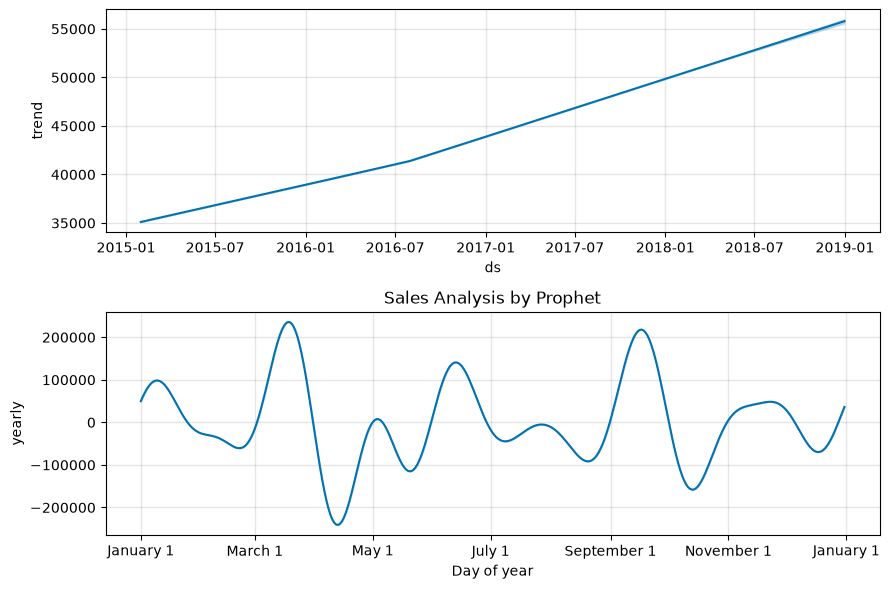

In [55]:

model_fb.plot_components(forecast)
plt.title("Sales Analysis by Prophet")
plt.tight_layout()
plt.show()


There for find the next 3 months future prediction sales.

In [56]:
future_forecast= forecast.tail(3)

In [57]:
future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]


,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,50900.787409,42951.993497,58294.490411
46,2018-11-30,89710.818739,82369.342474,97500.987500
47,2018-12-31,89211.294928,81938.650710,96354.535804


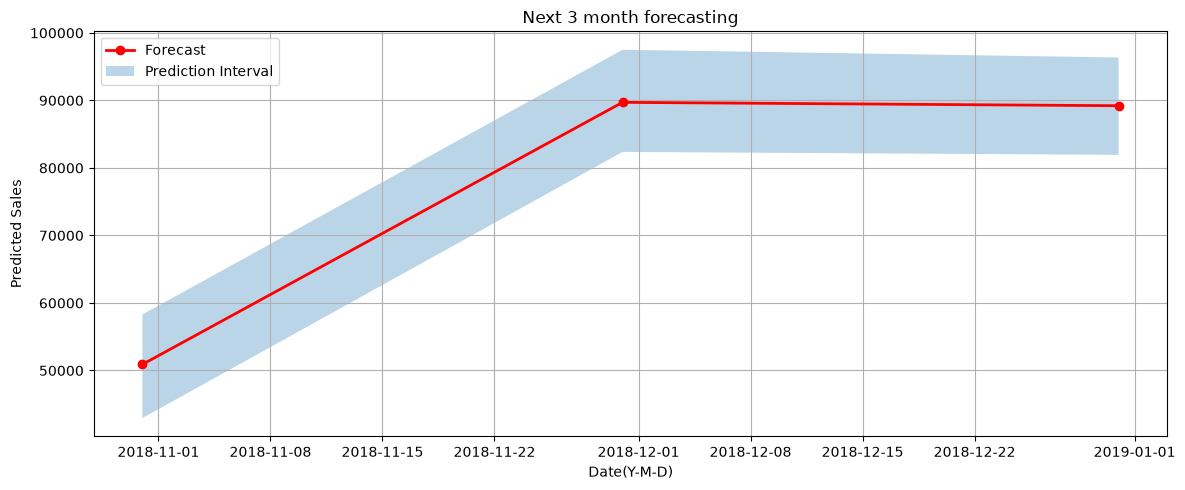

In [58]:
plt.figure(figsize=(12,5))

plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Forecast",
    color='r'
)

plt.fill_between(
    future_forecast['ds'],
    future_forecast['yhat_lower'],
    future_forecast['yhat_upper'],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Next 3 month forecasting")
plt.xlabel("Date(Y-M-D)")
plt.ylabel("Predicted Sales")
plt.savefig("./charts/fb- next 3 months.jpg")
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()

Now that is for weekly sales analysis.

In [59]:
prophet_daily= df.rename(columns={"Order Date":"ds","Sales":"y"})

In [60]:
model_daily = Prophet(weekly_seasonality=True,yearly_seasonality=False)
model_daily.fit(prophet_daily)

15:20:39 - cmdstanpy - INFO - Chain [1] start processing
15:20:40 - cmdstanpy - INFO - Chain [1] done processing


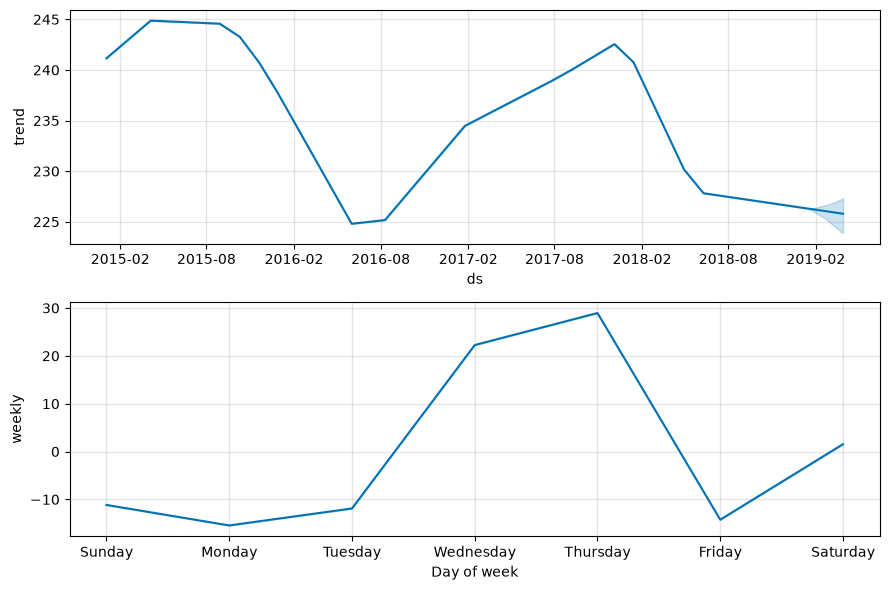

In [61]:
future_daily= model_daily.make_future_dataframe(periods=90,freq='D')
forecast_daily = model_daily.predict(future_daily)
model_daily.plot_components(forecast_daily)
plt.show()

By the insights clearly visual wednesday and thurday is the weekly trend must be growing.

Now MODEL: 3 XGBOOST that is machine learning based model and there is not specific need of data stationary or not or time seies data.

In [62]:
import xgboost as xgb

Copy monthly sales dataframe 

In [63]:
xgb_df= monthly_sales.copy()

In [64]:

xgb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  48 non-null     datetime64[us]
 1   Sales       48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes


In [65]:
xgb_df["Lag_1"]= xgb_df["Sales"].shift(1)
xgb_df["Lag_2"]= xgb_df["Sales"].shift(2)
xgb_df["Lag_3"]= xgb_df["Sales"].shift(3)


In [66]:
xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3
0,2015-01-31,14205.707,NaN,NaN,NaN
1,2015-02-28,4519.892,14205.707,NaN,NaN
2,2015-03-31,55205.797,4519.892,14205.707,NaN
3,2015-04-30,27906.855,55205.797,4519.892,14205.707
4,2015-05-31,23644.303,27906.855,55205.797,4519.892


In [67]:
xgb_df["Rolling_mean"] = xgb_df["Sales"].shift(1).rolling(min_periods=1,window=3).mean()
xgb_df["Month"]=df["Month"]
xgb_df["Quarter"]= df["Quarter"]
def get_season(Month):
    if Month in [12,1,2]:
      return 1
 
    elif Month in [3,4,5]:
       return 2
    
    elif Month in [6,7,8]:
       return 3
    
    else:
       return 4
    
xgb_df["Season"]= xgb_df["Month"].apply(get_season)
xgb_df.dropna(inplace=True)
print(xgb_df.head())

  Order Date       Sales       Lag_1       Lag_2      Lag_3  Rolling_mean  \
3 2015-04-30  27906.8550  55205.7970   4519.8920  14205.707  24643.798667   
4 2015-05-31  23644.3030  27906.8550  55205.7970   4519.892  29210.848000   
5 2015-06-30  34322.9356  23644.3030  27906.8550  55205.797  35585.651667   
6 2015-07-31  33781.5430  34322.9356  23644.3030  27906.855  28624.697867   
7 2015-08-31  27117.5365  33781.5430  34322.9356  23644.303  30582.927200   

   Month  Quarter  Season  
3     10        4       4  
4     10        4       4  
5      6        2       3  
6      6        2       3  
7      6        2       3  


Till now a time series data converted into fully supervised machine learning model. That is ready now with features for train.

There is fixed Y Which is main column like which is for predict. X valus which features for predict sales.

In [68]:
X = xgb_df[['Lag_1','Lag_2','Lag_3','Rolling_mean','Season','Quarter','Month']]
y = xgb_df['Sales']

In [69]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

Not random train test that is properly cronological (time based) train and test data and fit the labels , there trained in 33 samples and test only 12 sample.

In [70]:
X_train, X_test = X.iloc[:-12], X.iloc[-12:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]
print(f"Training Samples:{len(X_train)}, Testing Samole: {len(X_test)}")

Training Samples:33, Testing Samole: 12


there is using the xgbregressor model function that is best for when supervised ML is using

In [71]:
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)

Shape of X_train and X_test shapes.

In [72]:
print(X_train.shape)
print(X_test.shape)

(33, 7)
(12, 7)


That is actual visual insight actual sales vs XGBoost model prediction

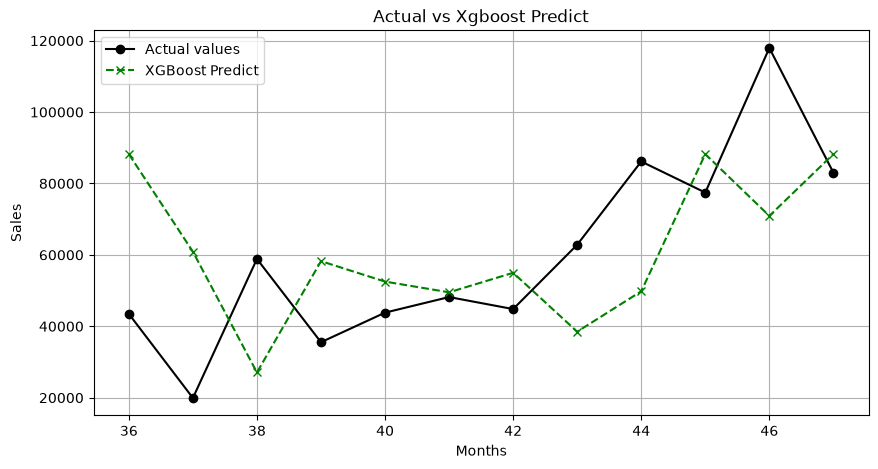

In [73]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Actual values",marker='o',color='black')
plt.plot(y_test.index, y_pred, label="XGBoost Predict", marker='x',color='green', linestyle='--' )
plt.title("Actual vs Xgboost Predict")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()
plt.savefig("./charts/XG- Actual vs predict.jpg")
plt.show()

That sales is shows previos 12 months data there is XGBoost predicted some surpised learning which is starting months that's why reason is XGBoost input depends on previos output because previos month is peak time of sales then the reason is  that for initial month gonna high sales Now forecast 3 months future sales.

Past 3 months Sales

Last row is defined for see last row.
important point which is made future dates which is makes for next 3 months of period end counr month ends only.

In [74]:
last_row = xgb_df.iloc[-1]

last_date = pd.to_datetime(xgb_df["Order Date"].iloc[-1])

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=3, freq='ME')

There is makes a list which is future prediction in this list work for future prediction values, and history sakes variable defined for rolling histoy sales analysis.

In [75]:
future_predictions = []

history_sales = [xgb_df['Sales'].iloc[-3], xgb_df['Sales'].iloc[-2], xgb_df['Sales'].iloc[-1]]
print(history_sales)

[np.float64(77448.1312), np.float64(117938.155), np.float64(83030.3888)]


In [76]:

for i, current_date in enumerate(future_dates):
    lag_1 = history_sales[-1]
    lag_2 = history_sales[-2]
    lag_3 = history_sales[-3]
    
    rolling_mean = np.mean([lag_1, lag_2, lag_3])
    
    month = current_date.month
    quarter = current_date.quarter
    
    if month in [12, 1, 2]:
        season = 1  # Winter
    elif month in [3, 4, 5]:
        season = 2  # Spring
    elif month in [6, 7, 8]:
        season = 3  # Summer
    else:
        season = 4  # Autumn
        
    current_features = pd.DataFrame([{
        'Lag_1': lag_1,
        'Lag_2': lag_2,
        'Lag_3': lag_3,
        'Rolling_mean': rolling_mean,
        'Season': season,
        'Quarter': quarter,
        'Month': month
        
    }])
    
    current_features = current_features[X_train.columns]
    pred_sales = model_xgb.predict(current_features)[0]
    
    future_predictions.append(pred_sales) #Save prediction
    
    history_sales.append(pred_sales)

    future_predictions = future_predictions[-len(future_dates):]
    
xgboost_forecast = pd.DataFrame({
    'Order Date': future_dates,
    'XGBoost_Forecast': future_predictions
})



In [77]:
print("--- Next 3 Months XGBoost Forecast ---")
print(xgboost_forecast)

--- Next 3 Months XGBoost Forecast ---
  Order Date  XGBoost_Forecast
0 2019-01-31       88220.78125
1 2019-02-28       88220.78125
2 2019-03-31       88220.78125


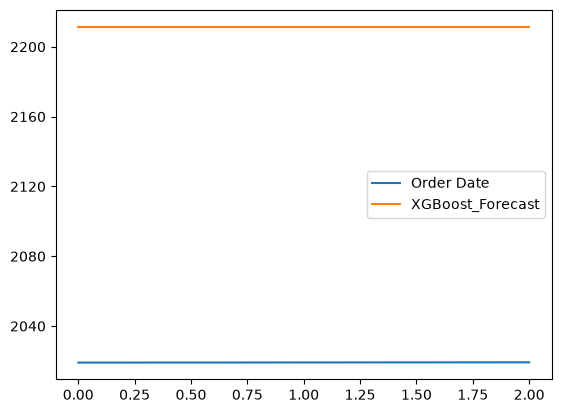

In [78]:
xgboost_forecast.plot()
plt.savefig("./charts/XG- m future.jpg")

For me same values of predictions gonna be seriously like unexpected then for verify of my model behavior i'm checked all that then i'm seened that is actual behavior of model not a Any type of bug

In [79]:
importance = pd.Series(
    model_xgb.feature_importances_,
    index=X_train.columns
)

print(importance.sort_values(ascending=False))

Rolling_mean    0.318956
Lag_3           0.210033
Lag_2           0.185937
Season          0.105808
Lag_1           0.093062
Quarter         0.078146
Month           0.008058
dtype: float32


The XGBoost model was trained using lag features, rolling mean, month, quarter, and season. During recursive forecasting, the predicted values converged to approximately ₹88,221 for all three future months. This occurred because the model was trained on only 33 monthly observations after feature engineering. As each prediction was fed back into the model as the next lag value, the input features became increasingly similar, causing the model to converge to a stable forecast. This is a common limitation of recursive machine learning forecasting on small datasets.

In [80]:
print(xgboost_forecast)
print(future_predictions)
print(history_sales)

  Order Date  XGBoost_Forecast
0 2019-01-31       88220.78125
1 2019-02-28       88220.78125
2 2019-03-31       88220.78125
[np.float32(88220.78), np.float32(88220.78), np.float32(88220.78)]
[np.float64(77448.1312), np.float64(117938.155), np.float64(83030.3888), np.float32(88220.78), np.float32(88220.78), np.float32(88220.78)]


Now comparison of all models

In [81]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error

xgb_mae = mean_absolute_error(y_test, y_pred)
print(xgb_mae)

xgb_rmse= np.sqrt(mean_squared_error(y_test, y_pred))
print(xgb_rmse)

xgb_mape= np.mean(np.abs((y_test - y_pred)/ y_test))*100
print(xgb_mape)

23672.754762499997
28366.20095733605
51.05747870943996


In [82]:
sarima_mae = mean_absolute_error(test["Sales"], sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test["Sales"], sarima_pred)
)

sarima_mape = np.mean(
    np.abs(
        (test["Sales"] - sarima_pred)/ test["Sales"]
    )
)*100

print(sarima_mae)
print(sarima_rmse)
print(sarima_mape)


14399.07928379272
19332.207980760893
28.420425377357283


In [83]:
prophet_mae = mean_absolute_error(test_prophet["y"], prophet_pred)
print(prophet_mae)

prophet_rmse = np.sqrt(mean_squared_error(test_prophet["y"],prophet_pred))
print(prophet_rmse)

prophet_mape = np.mean(
    np.abs(
        (test_prophet["y"]-prophet_pred)/test_prophet["y"])
)*100

print(prophet_mape)


9839.837362386028
14133.075502263819
15.668720420282764


In [84]:
prophet_forecast = forecast[["yhat"]].tail(3)
print(xgboost_forecast)

  Order Date  XGBoost_Forecast
0 2019-01-31       88220.78125
1 2019-02-28       88220.78125
2 2019-03-31       88220.78125


In [85]:
sarima_m1= sarima_pred.iloc[0]
sarima_m2= sarima_pred.iloc[1]
sarima_m3= sarima_pred.iloc[2]

prophet_m1 = prophet_forecast["yhat"].iloc[0]
prophet_m2 = prophet_forecast["yhat"].iloc[1]
prophet_m3 = prophet_forecast["yhat"].iloc[2]

xgb_m1= xgboost_forecast["XGBoost_Forecast"].iloc[0]
xgb_m2= xgboost_forecast["XGBoost_Forecast"].iloc[1]
xgb_m3= xgboost_forecast["XGBoost_Forecast"].iloc[2]


In [86]:
Model_Comparison = pd.DataFrame({
    "Model":["SARIMA",
              "FACEBOOK PROPHET",
              "XGBOOST"],
    
    "MAE":[sarima_mae,prophet_mae,xgb_mae],
    "RMSE":[sarima_rmse,prophet_rmse,xgb_rmse],
    "MAPE":[sarima_mape,prophet_mape,xgb_mape],
    "Forcast for 1m":[sarima_m1,prophet_m1,xgb_m1],
    "Forcast month 2":[sarima_m2,prophet_m2,xgb_m2],
    "Forecast month 3":[sarima_m3,prophet_m3,xgb_m3]
})
print(Model_Comparison)

              Model           MAE          RMSE       MAPE  Forcast for 1m  \
0            SARIMA  14399.079284  19332.207981  28.420425    41391.107016   
1  FACEBOOK PROPHET   9839.837362  14133.075502  15.668720    50900.787409   
2           XGBOOST  23672.754762  28366.200957  51.057479    88220.781250   

   Forcast month 2  Forecast month 3  
0     43103.594254      60511.580754  
1     89710.818739      89211.294928  
2     88220.781250      88220.781250  


Recommendation from me : Based on the evaluation metrics (MAE, RMSE, and MAPE), Facebook Prophet is recommended for production deployment. It achieved the lowest prediction errors among the three models, indicating the highest forecasting accuracy. Prophet also models trend and yearly seasonality automatically, making it well-suited for monthly sales forecasting. SARIMA provided reasonable performance but was less accurate than Prophet, while XGBoost struggled due to the limited amount of historical training data and the recursive forecasting approach.

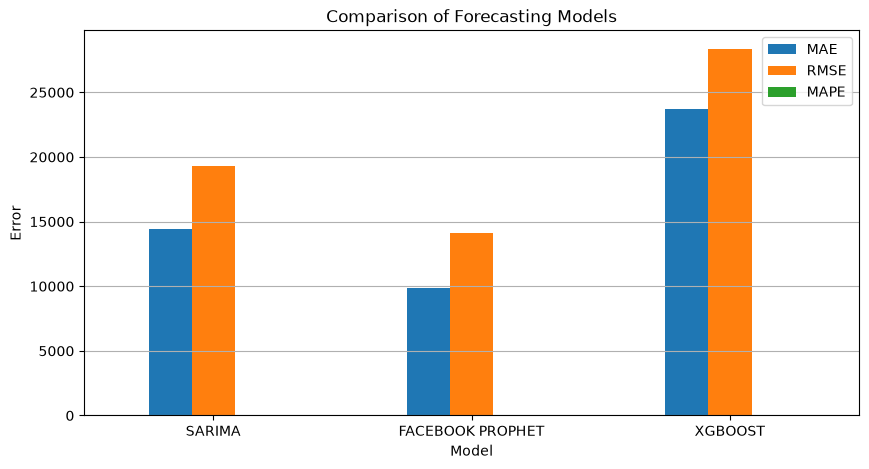

In [87]:
Model_Comparison.set_index("Model")[["MAE", "RMSE", "MAPE"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparison of Forecasting Models")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.savefig("./charts/Model Compare.jpg")
plt.show()

TASK 4: PRODUCT CATEGORY AND REGION LEVEL FORCASTING

Bcoz facebook prophet is  best model performance over than models, then forcast by the Prophet is best.

Firstly every segment define.

In [88]:
furniture = df[df["Category"] == "Furniture"]
technology = df[df["Category"] == "Technology"]
office = df[df["Category"] == "Office Supplies"]
west = df[df["Region"] == "West"]
east = df[df["Region"] == "East"]


Categorize Every columns and sum of particular subparts data monthly.

In [89]:
furniture_monthly = furniture.groupby(
    pd.Grouper(key='Order Date',freq='ME')
)["Sales"].sum().reset_index()

technology_monthly = technology.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

office_monthly = office.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

east_monthly = east.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

west_monthly = west.groupby(
    pd.Grouper(key="Order Date", freq="ME")
)["Sales"].sum().reset_index()

In [90]:
print(technology_monthly.head(2))

  Order Date    Sales
0 2015-01-31  3143.29
1 2015-02-28  1608.51


According Fb prophet rule there is rename column and rename into specific column which is 'ds','y'

In [91]:
furniture_prophet = furniture_monthly.rename(
    columns={"Order Date":"ds",
             "Sales":"y"
            }
)

technology_prophet = technology_monthly.rename(
    columns={"Order Date":"ds",
             "Sales":"y"
            }
)

office_prophet = office_monthly.rename(
    columns={"Order Date":"ds",
             "Sales":"y"}
)

east_prophet = east_monthly.rename(
    columns={"Order Date":"ds",
             "Sales":"y"}
)

west_prophet = west_monthly.rename(
    columns={"Order Date":"ds",
             "Sales":"y"}
)

Ready model to fit

In [92]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(furniture_prophet)

model_t = Prophet(yearly_seasonality=True,weekly_seasonality=False)
model_t.fit(technology_prophet)

model_o = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model_o.fit(office_prophet)

model_w = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model_w.fit(west_prophet)

model_e = Prophet(yearly_seasonality=True,weekly_seasonality=False)
model_e.fit(east_prophet)

15:20:47 - cmdstanpy - INFO - Chain [1] start processing
15:20:47 - cmdstanpy - INFO - Chain [1] done processing
15:20:48 - cmdstanpy - INFO - Chain [1] start processing
15:20:48 - cmdstanpy - INFO - Chain [1] done processing
15:20:48 - cmdstanpy - INFO - Chain [1] start processing
15:20:48 - cmdstanpy - INFO - Chain [1] done processing
15:20:49 - cmdstanpy - INFO - Chain [1] start processing
15:20:49 - cmdstanpy - INFO - Chain [1] done processing
15:20:49 - cmdstanpy - INFO - Chain [1] start processing
15:20:50 - cmdstanpy - INFO - Chain [1] done processing


In [93]:
future_f = model.make_future_dataframe(periods=3,freq="ME")
forecast_f = model.predict(future_f)
furniture_forecast = forecast_f.tail(3)

future_t = model_t.make_future_dataframe(periods=3,freq="ME")
forecast_t = model_t.predict(future_t)
technology_forecast = forecast_t.tail(3)

future_o = model_o.make_future_dataframe(periods=3, freq="ME")
forecast_o = model_o.predict(future_o)
office_forecast = forecast_o.tail(3)

future_e = model_e.make_future_dataframe(periods=3, freq="ME")
forecast_e = model_e.predict(future_e)
east_forecast = forecast_e.tail(3)

future_w = model_w.make_future_dataframe(periods=3, freq="ME")
forecast_w = model_w.predict(future_w)
west_forecast = forecast_w.tail(3)

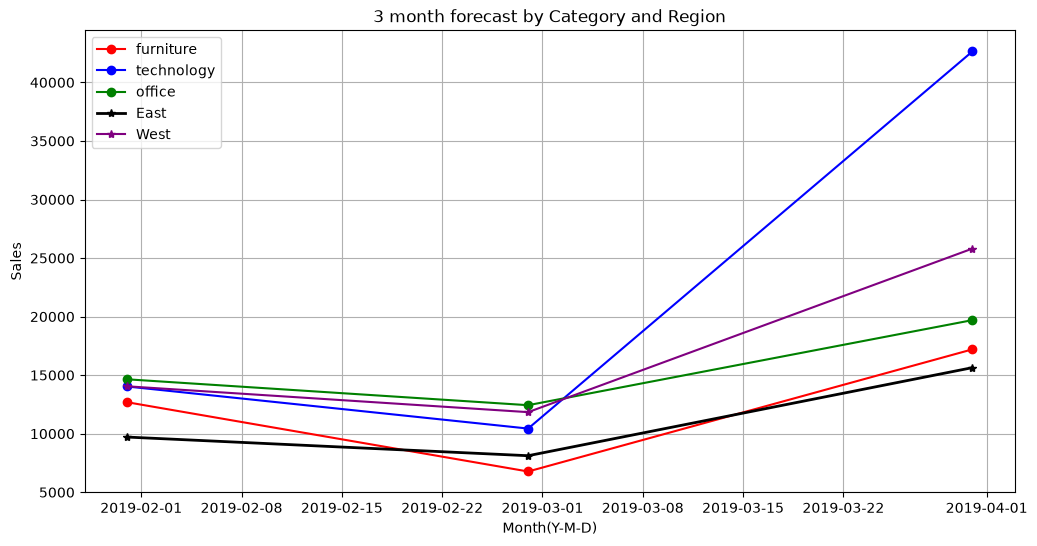

In [94]:
plt.figure(figsize=(12,6))

plt.plot(
    furniture_forecast["ds"],
    furniture_forecast["yhat"],
    marker="o",
    label="furniture",
    color='red'
)

plt.plot(
    technology_forecast["ds"],
    technology_forecast["yhat"],
    marker="o",
    label="technology",
    color='blue'
)

plt.plot(
    office_forecast["ds"],
    office_forecast["yhat"],
    marker="o",
    label="office",
    color='green'
)

plt.plot(
    east_forecast["ds"],
    east_forecast["yhat"],
    marker='*',
    linewidth=2,
    color="black",
    label='East'
)

plt.plot(
    west_forecast["ds"],
    west_forecast["yhat"],
    label="West",
    marker='*',
    color='purple'
)

plt.title("3 month forecast by Category and Region")
plt.xlabel("Month(Y-M-D)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.savefig("./charts/forecast category and region.jpg")
plt.show()

By this model i'm got in next 3 month forecasting technology is most growing in upcoming month sales. Technology start with around 13000 in first month and few down 15000 then the third month is on peak month for grow that gone 40000+ increased.if talk about initial month there is every sales decreasing every categories.

TASK 5: ANOMALY DETECTION 

Anomaly detection we can say which is unexpected term like in the 100,120,140,160,1000,200 there is 1000 is anomaly detection by this analysis we can find if unexpected up (offers,discount, holiday) that type if increase (system issu, stock unavailable on this time) thats why anomaly detection.

In [95]:
weekly_sales= (
    df.groupby(
        pd.Grouper(key="Order Date",freq="W")
        )["Sales"].sum().reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [96]:
from sklearn.ensemble import IsolationForest

In [97]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
weekly_sales["Anomaly"]= iso.fit_predict(weekly_sales[["Sales"]])

-1 means Anomaly andz 1 means normal there also first row of data is shows anomaly which is also like unexpected sales decreased

In [98]:
weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


In [99]:
anomallies = weekly_sales[
    weekly_sales["Anomaly"]==-1
]

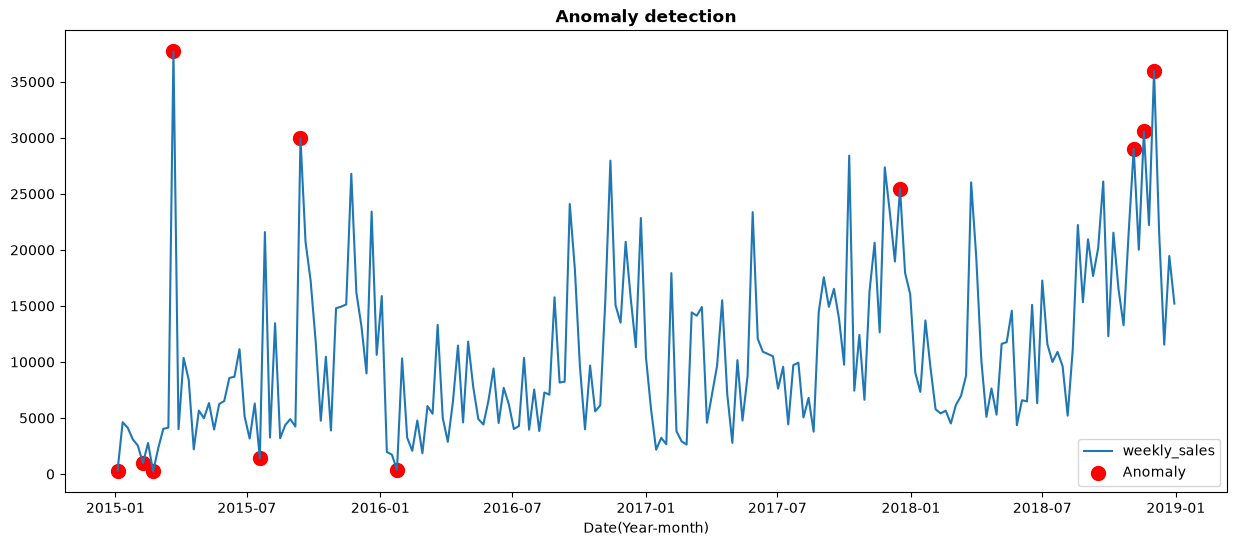

In [100]:
plt.figure(figsize=(15,6))
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label= "weekly_sales"
)

plt.scatter(
    anomallies["Order Date"],
    anomallies["Sales"],
    color='red',
    label= "Anomaly",
    s=100
)
plt.legend()
plt.title("Anomaly detection",fontweight='bold')
plt.xlabel("Date(Year-month)")
plt.savefig("./charts/Anomaly detected.jpg")
plt.show()

There is show anomaly values visualized key insights which is outlier and according to that company will know the reason in particular date happen.

In [101]:
print(anomallies)

    Order Date      Sales  Anomaly
0   2015-01-04    304.508       -1
5   2015-02-08    968.534       -1
7   2015-02-22    224.912       -1
11  2015-03-22  37703.665       -1
28  2015-07-19   1387.686       -1
36  2015-09-13  29959.137       -1
55  2016-01-24    358.522       -1
154 2017-12-17  25449.800       -1
200 2018-11-04  29017.467       -1
202 2018-11-18  30572.447       -1
204 2018-12-02  35998.900       -1


I think that's data when the company in startup that's why like increasing for lower. Starting anomallies we can say usually when the startup of any company or that was time when sales are dorn starting of the year and also analyzed in overall dataset pattern.
When talk about increased outlier like 204,202,200 index sales which is very high First of all that is peak time for every sale like E-MART, online shopping shop there are many offers valid like Mega sale offer and 04=11-2018 on this day is deepotsav event oraganized by ayodhya mandir not a specific day but yah its year end time. In dec 2018 that was big sign for sales up that's everyone excited about X-MAS then it is reason and in this time we see maybe Winter sales. Most of the anomallies increases when the time is end of the year But there is big twist it's obsolutely unexpected which the day of 22-03-2015 That is march month and day is sunday there confident about Any sales offer is launched that's why its highly increased.

Now anamoly detection by Z-Score.
that work in (current sale - rolling mean)/ rollling Std

In [102]:
weekly_sales["Rolling_mean"]=(weekly_sales["Sales"].rolling(window=4).mean())
weekly_sales["Rolling_std"]=(weekly_sales["Sales"].rolling(window=4).std())

In [103]:
weekly_sales["Z-score"]= (
    (
        weekly_sales["Sales"] - weekly_sales["Rolling_mean"]
    )
    /
    weekly_sales["Rolling_std"]
)


In [104]:
weekly_sales["z_anomaly"] = (
    abs(
      weekly_sales["Z-score"]
    )>2
)

In [105]:
weekly_sales[weekly_sales["z_anomaly"]]

,Order Date,Sales,Anomaly,Rolling_mean,Rolling_std,Z-score,z_anomaly


In [106]:
comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "z_anomaly"
    ]
]

print(comparison)

    Order Date       Sales  Anomaly  z_anomaly
0   2015-01-04    304.5080       -1      False
1   2015-01-11   4619.1080        1      False
2   2015-01-18   4130.5330        1      False
3   2015-01-25   3092.5440        1      False
4   2015-02-01   2527.9140        1      False
..         ...         ...      ...        ...
204 2018-12-02  35998.9000       -1      False
205 2018-12-09  21537.2410        1      False
206 2018-12-16  11542.8340        1      False
207 2018-12-23  19457.0680        1      False
208 2018-12-30  15210.8858        1      False

[209 rows x 4 columns]


Week of 2 December 2018: Sales were unusually high. A possible explanation is increased year-end shopping, holiday promotions, or a seasonal sales campaign.
Week of 4 January 2015: Sales were unusually low. This could indicate the beginning of the dataset, reduced post-holiday demand, or incomplete weekly sales records.

TASK 6: PRODUCT DEMAND SEGMENTATION USING CLUSTERING 

In [107]:
sales_volume = df.groupby("Sub-Category")["Sales"].sum()
avg_order = df.groupby("Sub-Category")["Sales"].mean()

For Sales volatility

In [108]:
monthly= df.groupby(
    ["Sub-Category",
     pd.Grouper(key= "Order Date",freq="ME")
    ]
)["Sales"].sum().reset_index()

In [109]:
violatility = monthly.groupby("Sub-Category")["Sales"].std()

For growth rate.

In [110]:
yearly = df.groupby(
    ["Sub-Category",
     df["Order Date"].dt.year]
)["Sales"].sum().reset_index()
print(yearly)

   Sub-Category  Order Date       Sales
0   Accessories        2015  23766.3960
1   Accessories        2016  40443.9700
2   Accessories        2017  41735.3640
3   Accessories        2018  58240.9700
4    Appliances        2015  15160.7150
..          ...         ...         ...
63     Supplies        2018  15952.1100
64       Tables        2015  45757.7775
65       Tables        2016  35397.1955
66       Tables        2017  60762.1125
67       Tables        2018  60893.5425

[68 rows x 3 columns]


In [111]:
yearly["Growth"] = yearly.groupby(
    "Sub-Category"
)["Sales"].pct_change()

In [112]:
growth = yearly.groupby("Sub-Category")["Growth"].mean()

In [113]:
cluster_df = pd.DataFrame({
    "Sales volume":sales_volume,
    "Growth Rate":growth,
    "Violatility":violatility,
    "Average order value":avg_order
})

In [114]:
cluster_df.head()

,Sales volume,Growth Rate,Violatility,Average order value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224


In [115]:
cluster_df.shape

(17, 4)

In [116]:
cluster_df.isnull().sum()

Sales volume           0
Growth Rate            0
Violatility            0
Average order value    0
dtype: int64

Now ready to use K-means clustering

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

In [118]:
print(scaled_data.shape)

(17, 4)


In [119]:
wcss= []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

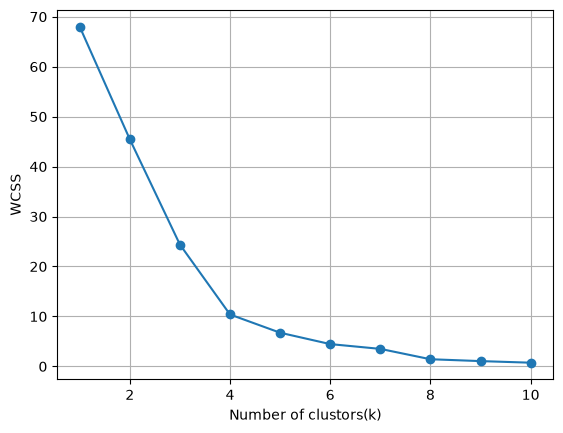

In [120]:
plt.Figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("Number of clustors(k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("./charts/kmeans choose.jpg")
plt.show()

The Elbow Method was used to determine the optimal number of clusters. The WCSS curve showed a clear elbow at K = 4, indicating that four clusters provide a good balance between minimizing within-cluster variance and avoiding unnecessary model complexity.

Because after cluster 4 getting extra curve plain side then 4 K is best

In [121]:
Kmeans= KMeans(
    n_clusters=4,
    random_state=42
)

cluster_df["Cluster"] = Kmeans.fit_predict(scaled_data)
cluster_df.head()

,Sales volume,Growth Rate,Violatility,Average order value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1


In [122]:
for i in range(4):
    print(f"\n Clusters {i}")
    print(cluster_df[cluster_df["Cluster"]==i].index.to_list())


 Clusters 0
['Copiers', 'Machines']

 Clusters 1
['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper']

 Clusters 2
['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']

 Clusters 3
['Supplies']


4 features, PCA reduces them to 2 dimensions for visualization.

In [126]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [128]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)
pca_df["Cluster"]= cluster_df["Cluster"].values
pca_df["Sub-Category"]= cluster_df.index

In [129]:
pca_df.head()

,PC1,PC2,Cluster,Sub-Category
0,0.032855,-0.128039,2,Accessories
1,-0.562213,0.137443,1,Appliances
2,-1.728503,-0.152657,1,Art
3,0.617483,-0.594676,2,Binders
4,-0.119791,-0.064887,1,Bookcases


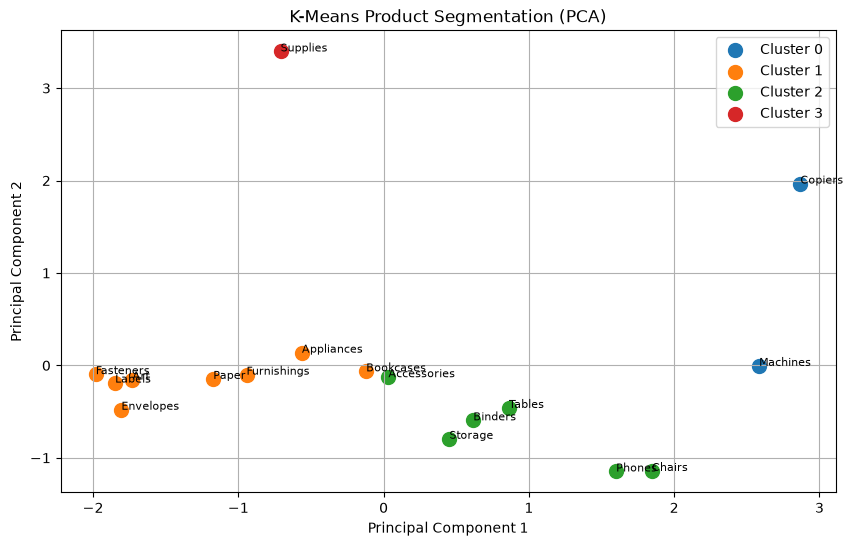

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in sorted(pca_df["Cluster"].unique()):
    temp = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster}",
        s=100
    )

    for _, row in temp.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=8
        )

plt.title("K-Means Product Segmentation (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.savefig("./charts/Kmeans product seg.jpg")
plt.show()

In [133]:
cluster_df.groupby("Cluster").mean(numeric_only=True)

,Sales volume,Growth Rate,Violatility,Average order value
Cluster,,,,
0,167743.362500,0.463389,5552.164569,1930.716763
1,55331.883212,0.199589,907.223743,129.054568
2,239495.780667,0.180965,3489.056075,361.131228
3,46420.308000,1.928448,2025.094139,252.284283


Based on the clustering results, products in the High Volume, Stable Demand cluster should be stocked in larger quantities because they consistently generate high sales. Products in the Low Volume, Stable Demand cluster require moderate inventory since their demand is predictable but relatively low. The High Value, High Volatility cluster should be managed carefully with safety stock and demand monitoring because these products are expensive and experience fluctuating demand. Finally, the Growing Demand cluster should receive gradually increasing inventory levels to support its rapidly increasing demand while avoiding excessive stock.

Cluster 0: High Value, High Volatility
Cluster 1: Low Volume, Stable Demand
Cluster 2: High Volume, Stable Demand
Cluster 3: Growing Demand